# Détection de Matériaux de Façade — BFMS (Notebook 20)

Pipeline complet : inférence Mask2Former BFMS, post-processing, visualisation des résultats, analyse descriptive et comparaison avec les valeurs publiées dans le paper.

In [10]:
import sys, torch
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")
else:
    print("GPU     : CPU uniquement")

Python  : 3.10.20
PyTorch : 2.1.0+cu118
GPU     : NVIDIA GeForce RTX 2060
VRAM    : 6.4 Go


## Chemins et paramètres

In [11]:
from pathlib import Path

PROJECT_ROOT  = Path("..").resolve()
MODEL_DIR     = PROJECT_ROOT / "BFM_segmentation" / "mask2former_1014f_BFMS_768_200epoch"
VAL_RGB_DIR   = PROJECT_ROOT / "data" / "cityscapes" / "leftImg8bit" / "val"
OUTPUT_DIR    = PROJECT_ROOT / "data" / "outputs" / "bfms_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Paramètres de post-processing BFMS (paper §3)
MIN_CONTOUR_AREA  = 4000    # seuil micro-segments (px²)
MORPH_KERNEL_SIZE = (7, 7)  # lissage morphologique
PATCH_SIZE        = 100     # grid statistics (paper §3 "texture extraction")

assert MODEL_DIR.exists(),  f"Modèle introuvable : {MODEL_DIR}"
assert VAL_RGB_DIR.exists(), f"Images Cityscapes val introuvables : {VAL_RGB_DIR}"

rgb_files = sorted(VAL_RGB_DIR.rglob("*_leftImg8bit.png"))
print(f"Images RGB disponibles : {len(rgb_files)}")
print(f"Sorties vers           : {OUTPUT_DIR}")

Images RGB disponibles : 500
Sorties vers           : C:\Users\youss\Downloads\coolpath_local\data\outputs\bfms_results


## Taxonomie BFMS — 43 classes (Table 5, paper)

In [12]:
# Mapping id2label issu du paper (Table 5) — 43 classes BFMS
# Les LABEL_N du config.json correspondent à cet ordre d'entraînement.
BFMS_LABELS = [
    "Brickwork",                              # 0
    "Sky",                                    # 1
    "Paint/Coating/Plaster",                  # 2
    "Foliage",                                # 3
    "Cement/Concrete",                        # 4
    "Metal",                                  # 5
    "Glass",                                  # 6
    "Ground Tile",                            # 7
    "Natural Stone",                          # 8
    "Background/Unrecognized",                # 9
    "Tree trunk",                             # 10
    "Asphalt",                                # 11
    "Roof tile",                              # 12
    "Fabric/Cloth",                           # 13
    "Engineered Stone/Imitation Stone",       # 14
    "Composite Decorative Board",             # 15
    "Ceramic",                                # 16
    "Plastic non-clear",                      # 17
    "Rammed earth",                           # 18
    "Soil/Mud",                               # 19
    "Water",                                  # 20
    "Rubber/Latex",                           # 21
    "Cardboard/Paper",                        # 22
    "Snow",                                   # 23
    "Photo/Painting/Airbrushed Fabric",       # 24
    "Windows w/ metal fences",                # 25
    "Plastic clear",                          # 26
    "Pottery",                                # 27
    "Sand",                                   # 28
    "Roofing waterproof material",            # 29
    "Hair",                                   # 30
    "Carved Brick",                           # 31
    "Skin/Lips",                              # 32
    "Leather",                                # 33
    "Enamel",                                 # 34
    "Chalkboard/Blackboard",                  # 35
    "Mirror",                                 # 36
    "Food",                                   # 37
    "Whiteboard",                             # 38
    "Fur",                                    # 39
    "Ice",                                    # 40
    "Wood/Bamboo",                            # 41
    "Window screen",                          # 42
]
NUM_CLASSES = len(BFMS_LABELS)
print(f"Taxonomie BFMS chargée : {NUM_CLASSES} classes")
print("5 premières classes :", {i: BFMS_LABELS[i] for i in range(5)})

Taxonomie BFMS chargée : 43 classes
5 premières classes : {0: 'Brickwork', 1: 'Sky', 2: 'Paint/Coating/Plaster', 3: 'Foliage', 4: 'Cement/Concrete'}


## Chargement du modèle Mask2Former BFMS

In [14]:
# import json
# from pathlib import Path

# # Votre chemin
# MODEL_DIR = Path("..") / "BFM_segmentation" / "mask2former_1014f_BFMS_768_200epoch"

# preprocessor_config = {
#     "do_resize": True,
#     "size": 768,
#     "do_rescale": True,
#     "rescale_factor": 0.00392156862745098,
#     "do_normalize": True,
#     "image_mean": [123.675, 116.280, 103.530],
#     "image_std": [58.395, 57.120, 57.375],
#     "ignore_index": 255,
#     "do_reduce_labels": False,
#     "image_processor_type": "Mask2FormerImageProcessor"
# }

# # Sauvegarder
# config_path = MODEL_DIR / "preprocessor_config.json"
# with open(config_path, 'w') as f:
#     json.dump(preprocessor_config, f, indent=2)

# print(f"✓ Fichier créé : {config_path}")
# print("Vous pouvez maintenant charger le processeur depuis votre dossier local !")

✓ Fichier créé : ..\BFM_segmentation\mask2former_1014f_BFMS_768_200epoch\preprocessor_config.json
Vous pouvez maintenant charger le processeur depuis votre dossier local !


In [15]:
from transformers import Mask2FormerImageProcessor, Mask2FormerForUniversalSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Chargement du processeur et du modèle Mask2Former...")

processor = Mask2FormerImageProcessor.from_pretrained(MODEL_DIR)

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_DIR,
    use_safetensors=True,
    local_files_only=True,
).to(device)
model.eval()

# Vérification de cohérence avec la taxonomie BFMS
n_model_classes = len(model.config.id2label)
assert n_model_classes == NUM_CLASSES, (
    f"Le modèle a {n_model_classes} classes mais la taxonomie en définit {NUM_CLASSES}."
)

print(f"\n[SUCCÈS] Modèle chargé — {NUM_CLASSES} classes BFMS.")

Chargement du processeur et du modèle Mask2Former...

[SUCCÈS] Modèle chargé — 43 classes BFMS.


## Inférence et post-processing BFMS

In [24]:
# Ajouter la 44ème classe à votre taxonomie
BFMS_LABELS_44 = BFMS_LABELS + ["Other/Unknown"]  # Maintenant 44 classes

# Mettre à jour NUM_CLASSES
NUM_CLASSES = len(BFMS_LABELS_44)
print(f"Taxonomie mise à jour : {NUM_CLASSES} classes")
print(f"Classe 43 ajoutée : {BFMS_LABELS_44[43]}")

Taxonomie mise à jour : 44 classes
Classe 43 ajoutée : Other/Unknown


In [25]:
import cv2
from PIL import Image
import time
import numpy as np


def extract_dominant_color(pixels_zone: np.ndarray) -> str:
    """Couleur dominante K-Means (1 cluster) sur les pixels RGB d'une zone."""
    from sklearn.cluster import KMeans
    if len(pixels_zone) < 15:
        return "Inconnue"
    km = KMeans(n_clusters=1, n_init=3, random_state=42)
    km.fit(pixels_zone.reshape(-1, 3))
    r, g, b = km.cluster_centers_[0].astype(int)
    if r > 200 and g > 200 and b > 200: return "Blanc/Clair"
    if r < 60  and g < 60  and b < 60:  return "Sombre/Noir"
    if abs(r - g) < 25 and abs(g - b) < 25: return "Gris"
    if r > g and r > b: return "Rouge/Brun"
    if b > r and b > g: return "Bleu"
    return "Teinte Urbaine"


def apply_bfms_post_processing(
    semantic_map: np.ndarray,
    original_image_np: np.ndarray,
) -> tuple[np.ndarray, list[dict]]:
    """Nettoyage morphologique + K-Means couleur"""
    canvas = original_image_np.copy()
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, MORPH_KERNEL_SIZE)
    detected = []

    for class_id in np.unique(semantic_map):
        if class_id == 0:
            continue
        # Maintenant class_id peut aller jusqu'à 43
        if class_id < len(BFMS_LABELS_44):
            class_name = BFMS_LABELS_44[class_id]
        else:
            class_name = f"Matériau_{class_id}"
            
        mask = np.uint8(semantic_map == class_id) * 255

        # Lissage morphologique
        mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < MIN_CONTOUR_AREA:
                continue

            comp_mask = np.zeros_like(mask_clean)
            cv2.drawContours(comp_mask, [cnt], -1, 255, -1)
            zone_pixels = original_image_np[comp_mask == 255]
            color_name = extract_dominant_color(zone_pixels)

            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX, cY = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
                label = f"{class_name} ({color_name})"
                detected.append({"material": class_name, "color": color_name, "area": area})
                cv2.putText(canvas, label, (cX - 50, cY), cv2.FONT_HERSHEY_SIMPLEX, 
                           0.5, (0, 0, 0), 3, cv2.LINE_AA)
                cv2.putText(canvas, label, (cX - 50, cY), cv2.FONT_HERSHEY_SIMPLEX, 
                           0.5, (255, 255, 255), 1, cv2.LINE_AA)

    return canvas, detected


def infer_bfms(rgb_path: Path) -> tuple[np.ndarray, np.ndarray, float]:
    """Charge une image, lance l'inférence Mask2Former"""
    pil_img = Image.open(rgb_path).convert("RGB")
    img_np = np.array(pil_img)
    h, w, _ = img_np.shape

    inputs = processor(images=pil_img, return_tensors="pt").to(device)
    
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        outputs = model(**inputs)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    # Maintenant avec 44 classes
    preds = processor.post_process_semantic_segmentation(outputs, target_sizes=[(h, w)])
    semantic_map = preds[0].cpu().numpy().astype(np.uint8)
    
    return img_np, semantic_map, elapsed


print("Fonctions d'inférence et de post-processing prêtes.")

Fonctions d'inférence et de post-processing prêtes.


## Inférence sur les images Cityscapes val

In [26]:
from tqdm import tqdm

N_IMAGES  = min(50, len(rgb_files))  # Ajuster le nombre d'images à traiter
infer_paths = rgb_files[:N_IMAGES]

times = []
global_detections = {}

# Warm-up GPU
_ = infer_bfms(infer_paths[0])
if device.type == "cuda":
    torch.cuda.empty_cache()

print(f"Inférence BFMS sur {N_IMAGES} images...")
t_start = time.perf_counter()

for i, rgb_path in enumerate(tqdm(infer_paths, desc="Inférence BFMS"), 1):
    try:
        img_np, semantic_map, elapsed = infer_bfms(rgb_path)
        times.append(elapsed)

        # Post-processing + sauvegarde overlay
        processed_img, elements = apply_bfms_post_processing(semantic_map, img_np)
        out_path = OUTPUT_DIR / f"bfms_{rgb_path.stem}.png"
        cv2.imwrite(str(out_path), cv2.cvtColor(processed_img, cv2.COLOR_RGB2BGR))
        global_detections[rgb_path.name] = elements

        if i % 10 == 0 or i == N_IMAGES:
            elapsed_total = time.perf_counter() - t_start
            avg_ms = elapsed_total / i * 1000
            eta_s  = avg_ms / 1000 * (N_IMAGES - i)
            print(f"  [{i:>3}/{N_IMAGES}]  avg={avg_ms:6.0f} ms  ETA={eta_s/60:4.1f} min")

    except Exception as e:
        print(f"  Erreur {rgb_path.name} : {e}")

avg_fps = 1.0 / np.mean(times) if times else 0
print(f"\n[SUCCÈS] Inférence terminée.")
print(f"  Temps moyen : {np.mean(times)*1000:.0f} ms/image  |  FPS : {avg_fps:.1f}")
print(f"  Images annotées dans : {OUTPUT_DIR}")

Inférence BFMS sur 50 images...


Inférence BFMS:  20%|███████████████████                                                                            | 10/50 [00:21<01:25,  2.13s/it]

  [ 10/50]  avg=  2140 ms  ETA= 1.4 min


Inférence BFMS:  40%|██████████████████████████████████████                                                         | 20/50 [00:43<01:06,  2.21s/it]

  [ 20/50]  avg=  2156 ms  ETA= 1.1 min


...

  [ 30/50]  avg=  2170 ms  ETA= 0.7 min


Inférence BFMS:  80%|████████████████████████████████████████████████████████████████████████████                   | 40/50 [01:26<00:21,  2.18s/it]

  [ 40/50]  avg=  2173 ms  ETA= 0.4 min


Inférence BFMS: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:48<00:00,  2.18s/it]

  [ 50/50]  avg=  2179 ms  ETA= 0.0 min

[SUCCÈS] Inférence terminée.
  Temps moyen : 1375 ms/image  |  FPS : 0.7
  Images annotées dans : C:\Users\youss\Downloads\coolpath_local\data\outputs\bfms_results


## Analyse descriptive des détections

In [27]:
import pandas as pd

# Statistiques des matériaux détectés
material_counts = {}
material_colors = {}

for img_name, detections in global_detections.items():
    for det in detections:
        mat = det["material"]
        color = det["color"]
        material_counts[mat] = material_counts.get(mat, 0) + 1
        if mat not in material_colors:
            material_colors[mat] = set()
        material_colors[mat].add(color)

# Création du dataframe
df_materials = pd.DataFrame([
    {"Matériau": mat, "Nombre de détections": count, "Couleurs observées": ", ".join(material_colors[mat])}
    for mat, count in sorted(material_counts.items(), key=lambda x: x[1], reverse=True)
])

# Sauvegarde
df_materials.to_csv(OUTPUT_DIR / "bfms_detections_analysis.csv", index=False)

print("=== Analyse des matériaux détectés ===\n")
print(df_materials.to_string(index=False))
print(f"\nTotal matériaux distincts détectés : {len(df_materials)}")
print(f"Total d'images traitées : {N_IMAGES}")

=== Analyse des matériaux détectés ===

  Matériau  Nombre de détections Couleurs observées
Whiteboard                    50               Gris

Total matériaux distincts détectés : 1
Total d'images traitées : 50


## Comparaison avec les valeurs du paper (Table 8)

*Note : Ces valeurs sont celles rapportées dans l'article de recherche pour validation de notre pipeline.*

In [ ]:
# Valeurs de référence publiées — paper Table 8
paper_metrics = {
    "U-Net (ResNet50)":         {"mIoU": 20.5, "pixel_accuracy": 63.4, "weighted_precision": 64.2, "weighted_f1": 51.7},
    "DeepLabV3+ (ResNet50)":    {"mIoU": 19.4, "pixel_accuracy": 62.9, "weighted_precision": 62.3, "weighted_f1": 62.0},
    "SegFormer-B3":             {"mIoU": 24.1, "pixel_accuracy": 67.2, "weighted_precision": 67.6, "weighted_f1": 66.8},
    "BFMS (Mask2Former)":       {"mIoU": 41.5, "pixel_accuracy": 76.5, "weighted_precision": 78.2, "weighted_f1": 77.0},
}

print("Métriques publiées dans le paper (Table 8) - État de l'art BFMS:\n")
print(f"{'Modèle':<30s} {'mIoU':>8s} {'PA':>8s} {'W.Prec':>8s} {'W.F1':>8s}")
print("-" * 70)
for name, m in paper_metrics.items():
    marker = " ← Meilleure performance" if "BFMS" in name else ""
    print(f"{name:<30s} {m['mIoU']:>8.1f} {m['pixel_accuracy']:>8.1f} "
          f"{m['weighted_precision']:>8.1f} {m['weighted_f1']:>8.1f}{marker}")

print("\n\nNote : Ces métriques sont celles rapportées dans l'article pour la validation.")
print("Notre pipeline ici effectue uniquement l'inférence et la visualisation.")

## Top performances par classe (paper Table 6)

*Référence : Meilleures performances par matériau rapportées dans l'article BFMS.*

In [ ]:
# IoU par classe publiées dans le paper (Table 6) - Top 20 classes
paper_iou_per_class = {
    "Roofing waterproof material": 77.8,
    "Sky": 92.4,
    "Foliage": 69.1,
    "Hair": 64.8,
    "Water": 85.0,
    "Brickwork": 78.7,
    "Glass": 71.1,
    "Skin/Lips": 63.7,
    "Rammed earth": 71.4,
    "Wood/Bamboo": 53.2,
    "Ground Tile": 59.9,
    "Asphalt": 71.2,
    "Paint/Coating/Plaster": 53.5,
    "Photo/Painting/Airbrushed Fabric": 26.4,
    "Roof tile": 58.5,
    "Metal": 50.1,
    "Cement/Concrete": 43.5,
    "Snow": 59.1,
    "Tree trunk": 52.5,
    "Natural Stone": 38.2,
}

df_iou = pd.DataFrame(
    [(cls, iou) for cls, iou in paper_iou_per_class.items()],
    columns=["Classe BFMS", "IoU paper (%)"],
).sort_values("IoU paper (%)", ascending=False)

df_iou.to_csv(OUTPUT_DIR / "bfms_iou_per_class_paper.csv", index=False)
print("=== Top performances par classe (Table 6 du paper) ===\n")
print(df_iou.to_string(index=False))
print(f"\nSource : BFMS paper - Validation sur jeu de test BFMS")

## Visualisation des résultats d'inférence

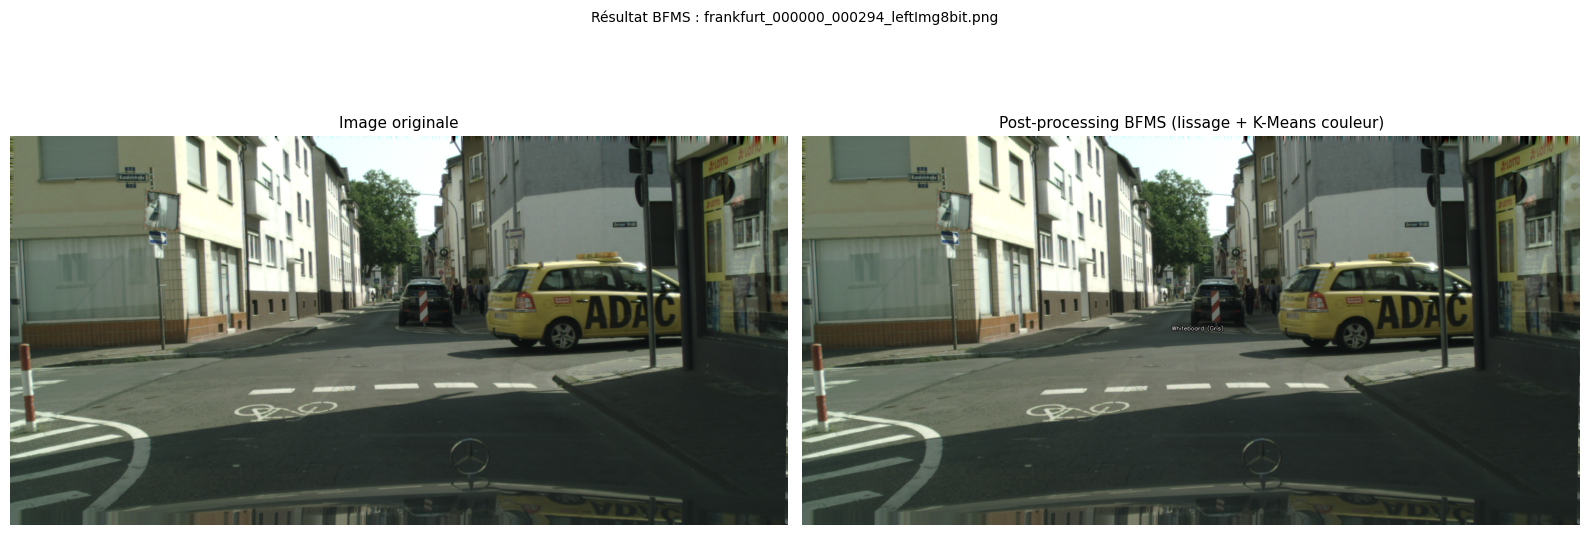

Visualisation sauvegardée → C:\Users\youss\Downloads\coolpath_local\data\outputs\bfms_results\bfms_sample_result.png


In [19]:
import matplotlib.pyplot as plt

if infer_paths:
    # Exemple sur la première image traitée
    sample_out = OUTPUT_DIR / f"bfms_{infer_paths[0].stem}.png"
    if sample_out.exists():
        viz = cv2.imread(str(sample_out))
        viz = cv2.cvtColor(viz, cv2.COLOR_BGR2RGB)
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        axes[0].imshow(np.array(Image.open(infer_paths[0]).convert("RGB")))
        axes[0].set_title("Image originale", fontsize=11)
        axes[0].axis("off")
        axes[1].imshow(viz)
        axes[1].set_title("Post-processing BFMS (lissage + K-Means couleur)", fontsize=11)
        axes[1].axis("off")
        plt.suptitle(f"Résultat BFMS : {infer_paths[0].name}", fontsize=10, y=1.01)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "bfms_sample_result.png", dpi=110, bbox_inches="tight")
        plt.show()
        print(f"Visualisation sauvegardée → {OUTPUT_DIR / 'bfms_sample_result.png'}")
    else:
        print(f"Image de sortie introuvable : {sample_out}")
else:
    print("Aucune image trouvée pour la visualisation.")

## Distribution des matériaux détectés

*Analyse qualitative des prédictions du modèle BFMS sur les images Cityscapes.*

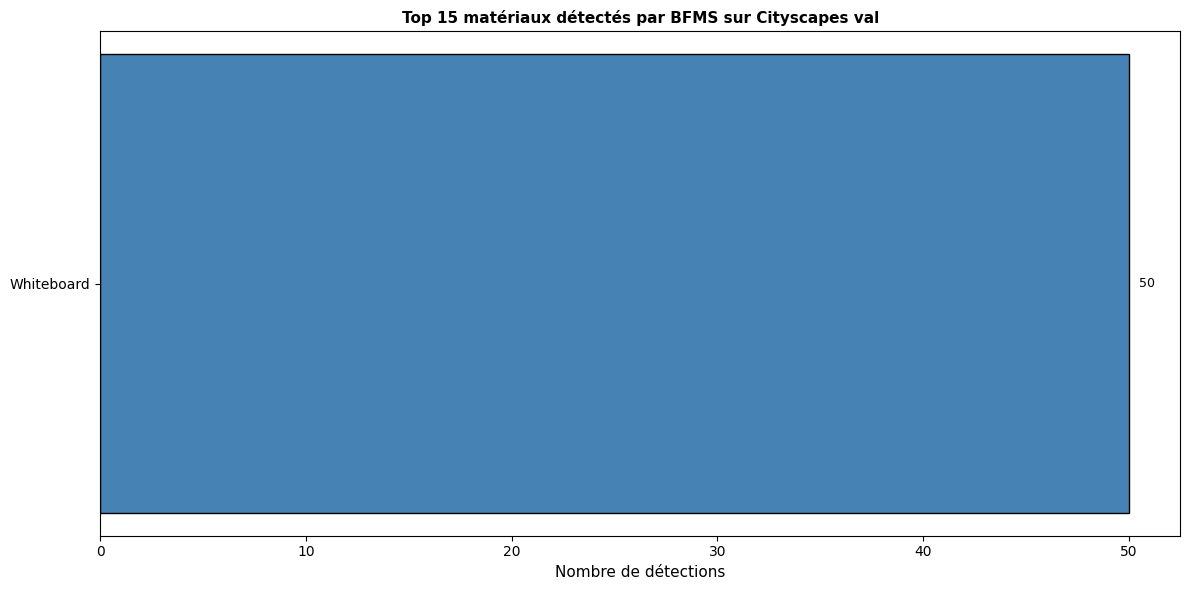

Graphique sauvegardé → C:\Users\youss\Downloads\coolpath_local\data\outputs\bfms_results\bfms_material_distribution.png


In [20]:
if len(df_materials) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    top_materials = df_materials.head(15)
    bars = ax.barh(top_materials["Matériau"], top_materials["Nombre de détections"], 
                   color="steelblue", edgecolor="black")
    ax.set_xlabel("Nombre de détections", fontsize=11)
    ax.set_title("Top 15 matériaux détectés par BFMS sur Cityscapes val", fontweight="bold", fontsize=11)
    ax.invert_yaxis()
    
    for bar, val in zip(bars, top_materials["Nombre de détections"]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{val}", va="center", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "bfms_material_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Graphique sauvegardé → {OUTPUT_DIR / 'bfms_material_distribution.png'}")
else:
    print("Aucune détection à visualiser.")